# Part I: Isotropic Scattering

First, I'm going to define the coordinate rotation described in the appendix as a function. In order to find out the value of $\Theta$ for each photon, we need to solve the cumulative distribution function given in the homework for cos $\Theta$. Since:

$$
P(x)=1
$$

we have

$$
C(\cos\Theta)
=
\frac{1}{2}
\int_{-1}^{\cos\Theta} 1\,dx
$$

Evaluating the integral gives

$$
C(\cos\Theta)
=
\frac{1}{2}
\left[x\right]_{-1}^{\cos\Theta}
$$

$$
C(\cos\Theta)
=
\frac{1}{2}
\left(\cos\Theta - (-1)\right)
$$

$$
C(\cos\Theta)
=
\frac{1}{2}
\left(\cos\Theta + 1\right)
$$

Now we set the cumulative probability equal to a random number drawn from a uniform distribution:

$$
C(\cos\Theta) = \zeta
$$

where

$$
\zeta \sim U(0,1)
$$

Therefore,

$$
\zeta
=
\frac{1}{2}
\left(\cos\Theta + 1\right)
$$

Solving for cos $\Theta$,

$$
2\zeta = \cos\Theta + 1
$$

$$
\cos\Theta = 2\zeta - 1
$$

Thus, the scattering angle can be sampled using

$$
\boxed{
\cos\Theta = 2\zeta - 1
}
$$

As a result, I defined the coordinate rotation function as below:

In [14]:
import numpy as np 
import matplotlib.pyplot as plt

#########Define the function to get the incoming photon direction, change it to photon coordinates, and change it back to the new photon direction
def coordinate_rotation(k):


    # Incoming photon coordinate system
    zp = k 

    kx, ky, kz = zp

    # Define xp
    horizontal_norm = np.sqrt(kx**2 + ky**2)

    if horizontal_norm < 1e-10:  # For the special case when photon is nearly vertical
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horizontal_norm

    # Define yp
    yp = np.cross(zp, xp)

    # Draw isotropic scattering angles
    cos_theta = 2 * np.random.uniform(0,1) - 1
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = 2 * np.pi * np.random.uniform(0,1)

    # Scattered direction in photon coordinates
    kp = np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta
    ])


    # Rotate back into model coordinates
    knew = kp[0] * xp + kp[1] * yp + kp[2] * zp

    return knew

Now, I'll define the core monte carlo model. The first section of the model is similar to what we had for homework 1, where the traveled optical depth by each photon was drawn from a uniformly distributed number between 0 to 1 and it would decide whether the photon survives all the way through the atmosphere to the surface or gets extinct. However, in the first homework, the extincted photons were only absorbed, whereas now there is a chance that the photon would be scattered, which is defined by the single scattering albedo $\tilde{\omega}$. After the initial decision on whether extinction would happen or survival to the surface, my model will work with the extinct photons and the $\tilde{\omega}$ to decide whether the photon is absorbed or scattered. If scattered, the model will enter a loop and calculate the pathlength the photon takes. This loop will continue for each individual scattered photon until either they reach one of the boundaries (TOA or surface) or get absorbed.

In [15]:
########Define the model 


def monte_carlo_scattering(N, tau_star, theta_deg, z_atm, omega, phi_deg, max_scatter=1000):
    
    theta0 = np.radians(theta_deg)
    phi0 = np.radians(phi_deg)

    if theta_deg >= 90:
        raise ValueError("Theta must be less than 90 degrees.")
    
    
    # Initial direction vector
    k0 = np.array([
        np.cos(phi0) * np.sin(theta0),
        np.sin(phi0) * np.sin(theta0),
        -np.cos(theta0)
    ])
    
    # Extinction coefficient for a homogeneous atmosphere
    beta_e = tau_star / z_atm
    
    # Arrays to store photons' traveled pathlengths
    final_pathlength = np.zeros(N)
    
    #stores how many times each photon scatters
    scatter_counts = np.zeros(N, dtype=int)
    
    #stores the final fate of each photon
    photon_fate = np.array(["survived"] * N, dtype=object)
    
    ###First pathlengths before an extinction event###
    
    zeta = np.random.uniform(0,1,N) #Here we assign a number between 0 and 1 (in this case absorption probability) to each photon
    
    #calculate the optical depth traveled by a photon before extinction 
    tau_traveled = -np.log(1-zeta)
    
    #calculate the physical pathlength traveled by each photon before extinction
    geometric_pathlength = (z_atm * tau_traveled) / (tau_star)
    
    #Distance to the surface in the initial direction
    distance_to_surface = z_atm / abs(k0[2])
    
    # Photons that reach surface before first extinction
    direct_surface_photons = geometric_pathlength >= distance_to_surface
    
    photon_fate[direct_surface_photons] = "direct_surface"
    
    final_pathlength[direct_surface_photons] = distance_to_surface
    
    # Photons that have extinction inside the atmosphere
    extinction = ~direct_surface_photons
    
    # Their first extinction height
    z_extinction = z_atm + geometric_pathlength * k0[2]

    # Store first path segment for extinct photons
    final_pathlength[extinction] = geometric_pathlength[extinction]
    
    
    ###Decision for scattering or absorption###
    
    #assign a random number to each photon and decide whether it is absorbed or scattered at the extinction event
    extinction_event = np.random.uniform(0, 1, N)
    absorbed = extinction & (extinction_event >= omega)
    scattered = extinction & (extinction_event < omega)
    
    photon_fate[absorbed] = "absorbed"
    
    ###Scattering loop###
    
    for i in np.where(scattered)[0]:
    
        #set the height of the photon to the extinction height
        z = z_extinction[i]
        #new direction after scattering transformed from the photon coordinates back to model coordinates
        k = coordinate_rotation(k0)
        #add a scattering event to the scatter count for this photon
        scatter_counts[i] = 1
        #mark the photon as alive
        alive = True
        
        while alive:
            # draw random optical depth to next extinction event
            zeta_scatter = np.random.uniform(0, 1)
            tau_traveled_scatter = -np.log(1 - zeta_scatter)
            # convert optical depth to geometric pathlength along photon path
            geometric_pathlength_scatter = (z_atm * tau_traveled_scatter) / (tau_star)
            # compute distance to boundary using current position and direction
            if k[2] < 0:
                distance_to_boundary = z / abs(k[2])
                boundary = "surface"

            elif k[2] > 0:
                distance_to_boundary = (z_atm - z) / k[2]
                boundary = "top of atmosphere"
            else:
                distance_to_boundary = np.inf
                boundary = None
                
            #check to see if the photon reaches any of the boundaries before the next extinction event
            if geometric_pathlength_scatter >= distance_to_boundary: #in this case the photon reaches TOA or surface after scattering
                final_pathlength[i] += distance_to_boundary
                if boundary == 'surface':
                    photon_fate[i] = "diffuse_surface"
                elif boundary == 'top of atmosphere':
                    photon_fate[i] = "reflected"
                alive = False
            else: #in this case the photon has another extinction event before reaching any boundary
                final_pathlength[i] += geometric_pathlength_scatter
                # move photon to extinction location
                z = z + geometric_pathlength_scatter * k[2]
                # decide absorption or scattering
                if np.random.uniform(0, 1) < omega:
                    k = coordinate_rotation(k)
                    scatter_counts[i] += 1
                    if scatter_counts[i] > max_scatter:
                        photon_fate[i] = "max_scatter_reached"
                        alive = False
                else:
                    photon_fate[i] = "absorbed"
                    alive = False


    N_direct_surface = np.sum(photon_fate == "direct_surface")
    N_diffuse_surface = np.sum(photon_fate == "diffuse_surface")
    N_reflected = np.sum(photon_fate == "reflected")
    N_absorbed_atm = np.sum(photon_fate == "absorbed")
    N_max_scatter = np.sum(photon_fate == "max_scatter_reached")
    
    results = {
        "N": N,
        "tau_star": tau_star,
        "theta_deg": theta_deg,
        "phi_deg": phi_deg,
        "mu0": np.abs(k0[2]),
        "omega": omega,

        "N_direct_surface": N_direct_surface,
        "N_diffuse_surface": N_diffuse_surface,
        "N_reflected": N_reflected,
        "N_absorbed_atm": N_absorbed_atm,
        "N_max_scatter": N_max_scatter,

        "direct_transmittance": N_direct_surface / N,
        "diffuse_transmittance": N_diffuse_surface / N,
        "total_surface_transmittance": (N_direct_surface + N_diffuse_surface) / N,
        "albedo": N_reflected / N,
        "atmospheric_absorptance": N_absorbed_atm / N,

        "photons fate": photon_fate,
        "final_pathlength": final_pathlength,
        "Extinction heights": z_extinction,
        "scatter_counts": scatter_counts
    }
    
    
    return results

In [16]:
##### Helper to print a summary table of the results
import pandas as pd
def summary(results):
    summary_keys = [
        "N",
        "tau_star",
        "theta_deg",
        "phi_deg",
        "mu0",
        "omega",
        "N_direct_surface",
        "N_diffuse_surface",
        "N_reflected",
        "N_absorbed_atm",
        "N_max_scatter",
        "direct_transmittance",
        "diffuse_transmittance",
        "total_surface_transmittance",
        "albedo",
        "atmospheric_absorptance",
        "photons fate",
        "final_pathlength",
        "Extinction heights",
        "scatter_counts"
    ]

    summary_table = pd.DataFrame({
        "quantity": summary_keys,
        "value": [results[key] for key in summary_keys]
    })

    return summary_table

# Validation 1

For the first test, I used a purely absorbing atmosphere case with optical depth of 1 and solar zenith angle of 0. Based on homework 1, the model should give a direct transmittance value of near 0.36, while showing zero for diffuse transmittance.

In [17]:
results = monte_carlo_scattering(100000, 1, 0, 8000, 0, 0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,100000
1,tau_star,1
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,0
6,N_direct_surface,36729
7,N_diffuse_surface,0
8,N_reflected,0
9,N_absorbed_atm,63271


# Validation 2

For the first test, I used a purely scattering atmosphere case with optical depth of 1 and solar zenith angle of 0. In this case, the model should show zero atmospheric absorption.

In [18]:
results = monte_carlo_scattering(100000, 1, 0, 8000, 1, 0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,100000
1,tau_star,1
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,1
6,N_direct_surface,36616
7,N_diffuse_surface,29293
8,N_reflected,34091
9,N_absorbed_atm,0


# Validation 3

For the first test, I used an atmosphere case with optical depth of 0 and solar zenith angle of 0. The model should show that all the photons reach the surface directly and no extinction happens in the atmosphere.

In [19]:
results = monte_carlo_scattering(100000, 0, 0, 8000, 1, 0, max_scatter=1000)
summary_table = summary(results)
summary_table

C:\Users\ehsan\AppData\Local\Temp\ipykernel_31248\2193722911.py:40: RuntimeWarning: divide by zero encountered in divide
  geometric_pathlength = (z_atm * tau_traveled) / (tau_star)


,quantity,value
0,N,100000
1,tau_star,0
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,1
6,N_direct_surface,100000
7,N_diffuse_surface,0
8,N_reflected,0
9,N_absorbed_atm,0


# Question a


The direct transmittance should stay approximately constant as the single scatter albedo, $\tilde{\omega}$, changes. This is because direct photons are photons that reach the surface without experiencing any extinction event. The probability of no extinction depends on the total optical depth and solar zenith angle, not on whether an extinction event would have been absorption or scattering.


The diffuse transmittance should increase as $\tilde{\omega}$ increases. When $$\tilde{\omega} = 0$$, every extinction event is absorption, so there is no diffuse radiation reaching the surface. As $\tilde{\omega}$ increases, more extinction events become scattering events. Some of those scattered photons are redirected downward and eventually reach the surface as diffuse radiation. As a result, the diffuse transmittance increases with increasing $\tilde{\omega}$.


The albedo should also increase as $\tilde{\omega}$ increases. This happens because more photons survive extinction events by scattering instead of being absorbed. Some of those scattered photons are redirected upward and escape through the top of the atmosphere. 

The plot below from the model results also indicates the same conclusion we can draw from analytical equations, showing an increase in diffuse transmittance and albedo as $\tilde{\omega}$ increases, while the direct transmittance is constant.

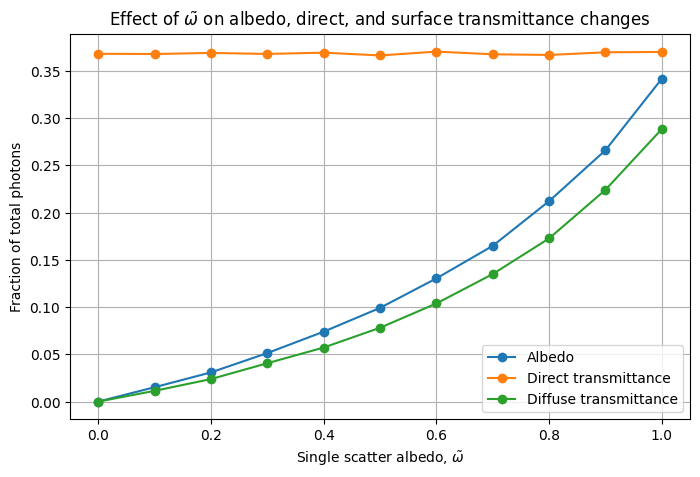

In [24]:
omega_values=np.linspace(0, 1, 11)

rows = []

for omega in omega_values:
    results = monte_carlo_scattering(
        N=100000,
        tau_star=1,
        theta_deg=0,
        z_atm=8000,
        omega=omega,
        phi_deg=0
    )

    rows.append({
        "omega": omega,
        "albedo": results["albedo"],
        "direct_transmittance": results["direct_transmittance"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "total_surface_transmittance": results["total_surface_transmittance"],
        "atmospheric_absorptance": results["atmospheric_absorptance"]
    })
    
omega_df = pd.DataFrame(rows)

plt.figure(figsize=(8, 5))

plt.plot(
    omega_df["omega"],
    omega_df["albedo"],
    marker="o",
    label="Albedo"
)
plt.plot(
    omega_df["omega"],
    omega_df["direct_transmittance"],
    marker="o",
    label="Direct transmittance"
)

plt.plot(
    omega_df["omega"],
    omega_df["diffuse_transmittance"],
    marker="o",
    label="Diffuse transmittance"
)

plt.xlabel(r"Single scatter albedo, $\tilde{\omega}$")
plt.ylabel("Fraction of total photons")
plt.title(r"Effect of $\tilde{\omega}$ on albedo, direct, and surface transmittance changes")
plt.grid(True)
plt.legend()
plt.show()


# Question b

For an optically thin atmosphere from the notes, the total transmittance can be written as:

$$
t = t_{\text{dir}} + t_{\text{dif}}
$$

where the diffuse contribution is

$$
t_{\text{dif}} =
\frac{F_0 \tilde{\omega} \tau^*}{4 \pi |\mu|}
p(\cos \Theta)
$$

This expression shows that diffuse radiation increases with increasing the incoming solar flux, the single scatter albedo, the optical depth, and decreasing $|\mu|$.

The important proportionality is

$$
t_{\text{dif}} \propto \frac{\tilde{\omega} \tau^*}{|\mu|}
$$

The phase function term,

$$
p(\cos \Theta)
$$

controls how much scattered radiation is sent into a particular direction.

In the Monte Carlo model, the direct solar beam travels through an effective slant optical depth of

$$
\frac{\tau^*}{\mu_0}
$$

where

$$
\mu_0 = \cos \theta_0
$$

The probability that a photon experiences at least one extinction event before reaching the surface is

$$
P_{\text{ext}} =
1 - e^{-\tau^*/\mu_0}
$$

For small optical depth, we use the approximation

$$
e^{-x} \approx 1 - x
$$

with

$$
x = \frac{\tau^*}{\mu_0}
$$

Therefore,

$$
P_{\text{ext}}
\approx
1 - \left(1 - \frac{\tau^*}{\mu_0}\right)
$$

so

$$
P_{\text{ext}}
\approx
\frac{\tau^*}{\mu_0}
$$

Only a fraction

$$
\tilde{\omega}
$$

of extinction events are scattering events. Therefore, the probability of a scattering event is approximately

$$
P_{\text{scat}}
\approx
\tilde{\omega}
\frac{\tau^*}{\mu_0}
$$

For isotropic scattering, photons are scattered equally into all directions. Therefore, approximately half of the scattered photons are directed into the downward hemisphere and can contribute to diffuse radiation reaching the surface.

Thus, the Monte Carlo estimate for diffuse surface transmittance is

$$
T_{\text{diffuse}}
\approx
\frac{1}{2}
\tilde{\omega}
\frac{\tau^*}{\mu_0}
$$

or

$$
T_{\text{diffuse}}
\approx
\frac{\tilde{\omega} \tau^*}{2 \mu_0}
$$

This is consistent with the analytical RTE expression from the notes,

$$
t_{\text{dif}} =
\frac{F_0 \tilde{\omega} \tau^*}{4 \pi |\mu|}
p(\cos \Theta)
$$



The plots below from the model results also confirm this, showing that the diffuse transmittance increases with increased optical depth and single scattering albedo, while decreases with reduction in $|\mu|$ values.

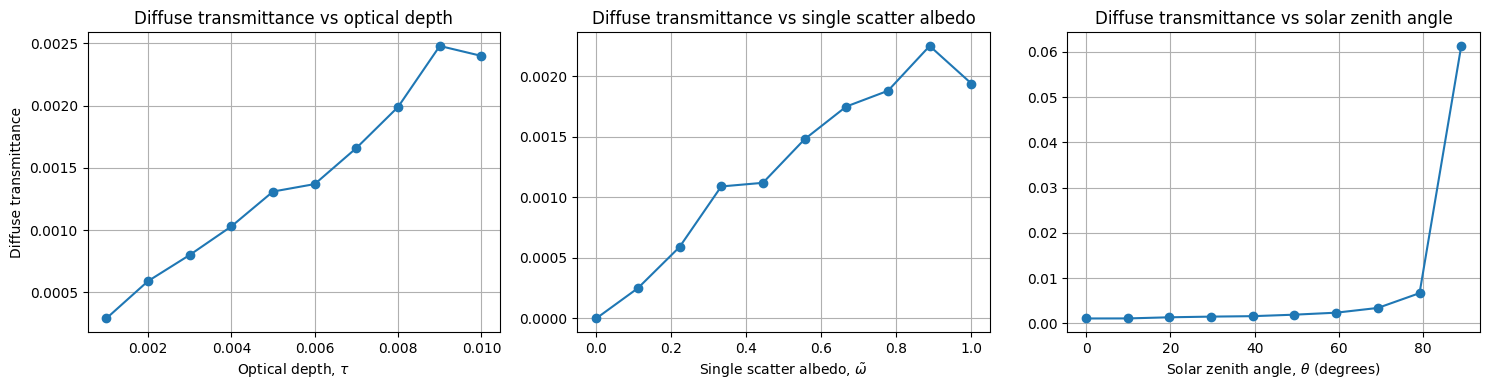

In [51]:
#######Monte carlo model for different optical depths
tau_values=np.linspace(0.001, 0.01, 10)

rows = []

for tau in tau_values:
    results = monte_carlo_scattering(
        N=100000,
        tau_star=tau,
        theta_deg=0,
        z_atm=8000,
        omega=0.5,
        phi_deg=0
    )

    rows.append({
        "tau": tau,
        "albedo": results["albedo"],
        "direct_transmittance": results["direct_transmittance"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "total_surface_transmittance": results["total_surface_transmittance"],
        "atmospheric_absorptance": results["atmospheric_absorptance"]
    })
    
tau_df = pd.DataFrame(rows)

#######Monte carlo model for different single scattering albedos
omega_values=np.linspace(0, 1, 10)

rows = []

for omega in omega_values:
    results = monte_carlo_scattering(
        N=100000,
        tau_star=0.005,
        theta_deg=0,
        z_atm=8000,
        omega=omega,
        phi_deg=0
    )

    rows.append({
        "omega": omega,
        "albedo": results["albedo"],
        "direct_transmittance": results["direct_transmittance"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "total_surface_transmittance": results["total_surface_transmittance"],
        "atmospheric_absorptance": results["atmospheric_absorptance"]
    })
    
omega_df = pd.DataFrame(rows)

#######Monte carlo model for different solar zenith angles
theta_values=np.linspace(0, 89, 10)

rows = []

for theta in theta_values:
    results = monte_carlo_scattering(
        N=100000,
        tau_star=0.005,
        theta_deg=theta,
        z_atm=8000,
        omega=0.5,
        phi_deg=0
    )

    rows.append({
        "theta": theta,
        "albedo": results["albedo"],
        "direct_transmittance": results["direct_transmittance"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "total_surface_transmittance": results["total_surface_transmittance"],
        "atmospheric_absorptance": results["atmospheric_absorptance"]
    })
    
theta_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(
    tau_df["tau"],
    tau_df["diffuse_transmittance"],
    marker="o"
)
axes[0].set_title("Diffuse transmittance vs optical depth")
axes[0].set_xlabel(r"Optical depth, $\tau$")
axes[0].set_ylabel("Diffuse transmittance")
axes[0].grid(True)

axes[1].plot(
    omega_df["omega"],
    omega_df["diffuse_transmittance"],
    marker="o"
)
axes[1].set_title("Diffuse transmittance vs single scatter albedo")
axes[1].set_xlabel(r"Single scatter albedo, $\tilde{\omega}$")
axes[1].grid(True)

axes[2].plot(
    theta_df["theta"],
    theta_df["diffuse_transmittance"],
    marker="o"
)
axes[2].set_title("Diffuse transmittance vs solar zenith angle")
axes[2].set_xlabel(r"Solar zenith angle, $\theta$ (degrees)")
axes[2].grid(True)



plt.tight_layout()
plt.show()

# Question c


From the notes, we know the extinction coefficient can be written as:

$$
\beta_e = \sigma_e N
$$

where $\beta_e$ is the volume extinction coefficient, $\sigma_e$ is the extinction cross section, and $N$ is the particle or molecule number concentration.

Optical depth is related to the extinction coefficient by:

$$
\tau = \int \beta_e(z) \, dz
$$

For a homogeneous atmosphere, this simplifies to:

$$
\tau = \beta_e z
$$

Based on internet search, rayleigh scattering cross section is:

$$
\sigma_s =
\frac{8\pi^3}{3\lambda^4}
\left(
\frac{n^2 - 1}{N}
\right)^2
$$

where $\lambda$ is wavelength. This shows:

$$
\sigma_s \propto \frac{1}{\lambda^4}
$$

Since the extinction coefficient is related to cross section, we can relate the optical depth to wavelength:


$$
\tau(\lambda) \propto \frac{1}{\lambda^4}
$$

This means that shorter wavelengths experience larger optical depths. Blue light has a shorter wavelength than red light, so

$$
\lambda_{\text{blue}} < \lambda_{\text{red}}
$$

and therefore

$$
\tau_{\text{blue}} > \tau_{\text{red}}
$$

As a result, blue light is scattered more strongly by the atmosphere than red light.

During the day, this stronger scattering redirects blue photons into the diffuse sky radiation, making the sky appear blue. Near sunset, the solar zenith angle is large, so sunlight travels through a much longer atmospheric path. Because blue light has a larger optical depth, it is scattered out of the direct solar beam more efficiently. By the time the direct sunlight reaches an observer near the horizon, much of the blue light has been removed, while more red light remains. This is why sunsets appear red. This is shown by the model results, where the diffuse transmittance of blue light is higher than red during the day and at sunset, the red light's direct transmittance dominates the atmosphere.

,color,wavelength_nm,tau,daytime_diffuse,daytime_direct,daytime_albedo,sunset_diffuse,sunset_direct,sunset_albedo
0,Blue,450,0.217657,0.06472,0.79454,0.06465,0.26380,0.08240,0.31415
1,Red,650,0.050000,0.01744,0.94898,0.01736,0.14848,0.56407,0.14765


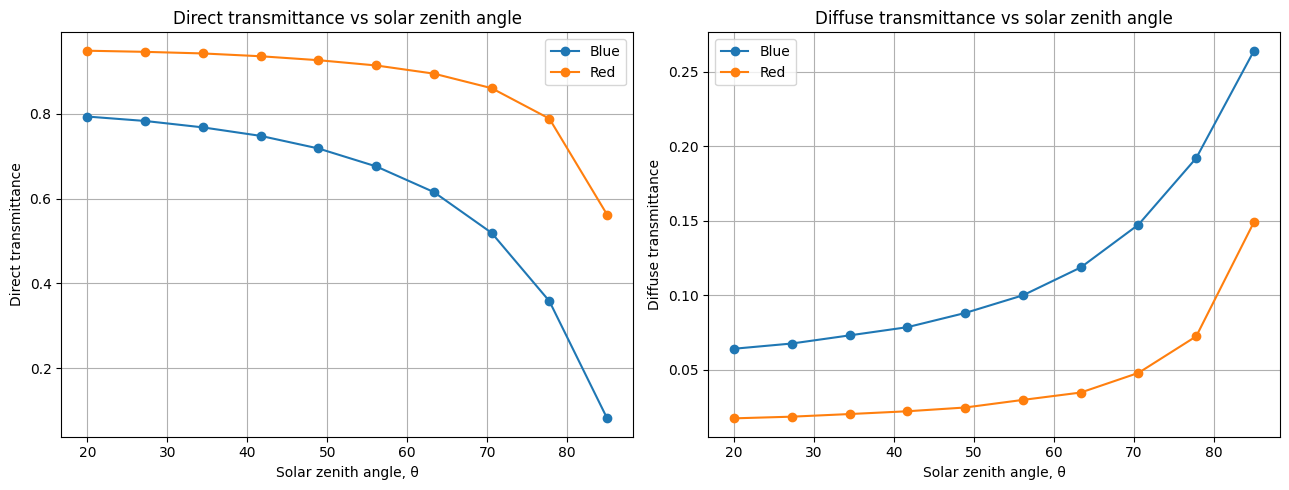

In [53]:
lambda_blue = 450  # nm
lambda_red = 650   # nm

tau_red = 0.05

tau_blue = tau_red * (lambda_red / lambda_blue)**4

######Daylight
theta_deg = 20
omega = 0.7
N = 100000
z_atm = 8000
phi_deg = 0

results_blue_daylight = monte_carlo_scattering(N, tau_blue, theta_deg, z_atm, omega, phi_deg)
results_red_daylight = monte_carlo_scattering(N, tau_red, theta_deg, z_atm, omega, phi_deg)

#####Sunset
theta_deg = 85

results_blue_sunset = monte_carlo_scattering(N, tau_blue, theta_deg, z_atm, omega, phi_deg)
results_red_sunset = monte_carlo_scattering(N, tau_red, theta_deg, z_atm, omega, phi_deg)

import pandas as pd
import matplotlib.pyplot as plt

wavelength_df = pd.DataFrame({
    "color": ["Blue", "Red"],
    "wavelength_nm": [lambda_blue, lambda_red],
    "tau": [tau_blue, tau_red],
    "daytime_diffuse": [
        results_blue_daylight["diffuse_transmittance"],
        results_red_daylight["diffuse_transmittance"]
    ],
    "daytime_direct": [
        results_blue_daylight["direct_transmittance"],
        results_red_daylight["direct_transmittance"]
    ],
    "daytime_albedo": [
        results_blue_daylight["albedo"],
        results_red_daylight["albedo"]
    ],
    "sunset_diffuse": [
        results_blue_sunset["diffuse_transmittance"],
        results_red_sunset["diffuse_transmittance"]
    ],
    "sunset_direct": [
        results_blue_sunset["direct_transmittance"],
        results_red_sunset["direct_transmittance"]
    ],
        "sunset_albedo": [
            results_blue_sunset["albedo"],
            results_red_sunset["albedo"]
        ]
})

display(wavelength_df)

theta_values=np.linspace(20, 85, 10)

rows = []

for theta_deg in theta_values:

        # Blue simulation
        results_blue = monte_carlo_scattering(
            N=N,
            tau_star=tau_blue,
            theta_deg=theta_deg,
            z_atm=z_atm,
            omega=omega,
            phi_deg=phi_deg
        )

        rows.append({
            "color": "Blue",
            "wavelength_nm": lambda_blue,
            "tau": tau_blue,
            "theta_deg": theta_deg,
            "mu0": np.cos(np.radians(theta_deg)),
            "direct_transmittance": results_blue["direct_transmittance"],
            "diffuse_transmittance": results_blue["diffuse_transmittance"],
            "albedo": results_blue["albedo"]
        })

        # Red simulation
        results_red = monte_carlo_scattering(
            N=N,
            tau_star=tau_red,
            theta_deg=theta_deg,
            z_atm=z_atm,
            omega=omega,
            phi_deg=phi_deg
        )

        rows.append({
            "color": "Red",
            "wavelength_nm": lambda_red,
            "tau": tau_red,
            "theta_deg": theta_deg,
            "mu0": np.cos(np.radians(theta_deg)),
            "direct_transmittance": results_red["direct_transmittance"],
            "diffuse_transmittance": results_red["diffuse_transmittance"],
            "albedo": results_red["albedo"]
        })

blue_red_results = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for color in ["Blue", "Red"]:
    subset = blue_red_results[blue_red_results["color"] == color]

    axes[0].plot(
        subset["theta_deg"],
        subset["direct_transmittance"],
        marker="o",
        label=color
    )

    axes[1].plot(
        subset["theta_deg"],
        subset["diffuse_transmittance"],
        marker="o",
        label=color
    )

axes[0].set_xlabel("Solar zenith angle, θ")
axes[0].set_ylabel("Direct transmittance")
axes[0].set_title("Direct transmittance vs solar zenith angle")
axes[0].grid(True)
axes[0].legend()

axes[1].set_xlabel("Solar zenith angle, θ")
axes[1].set_ylabel("Diffuse transmittance")
axes[1].set_title("Diffuse transmittance vs solar zenith angle")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



# Question d

My question: how does the diffuse transmittance of light at different wavelengths change when the optical depth of the atmosphere gets larger with a fixed zenith angle?

To answer this question, I defined the wavelengths for different colors in visible spectrum, consider the red light as the reference, and then run my model to calculate the diffuse transmittance change for each individual light as the optical depth increases. As the reference red optical depth increases, the dominant wavelength of diffuse transmittance shifts from shorter to longer wavelengths. At low optical depth, blue and violet wavelengths dominate the diffuse transmittance because Rayleigh scattering is strongest at short wavelengths. As optical depth increases, the shortest wavelengths become optically thick first, so blue and violet photons undergo many extinction events and are more likely to be absorbed or reflected before reaching the surface. Longer wavelengths, especially yellow, orange, and red, remain more transmissive and eventually dominate the diffuse radiation reaching the surface. Therefore, increasing atmospheric optical depth causes the modeled diffuse sky color to shift from blue toward a yellowish and then more red - orange ish diffuse light field.

In [ ]:
wavelengths = {
    "violet": 0.40,
    "blue": 0.45,
    "cyan": 0.50,
    "green": 0.55,
    "yellow": 0.58,
    "orange": 0.62,
    "red": 0.70
}

tau_ref_values = np.linspace(0.05, 1.0, 20)

lambda_ref = 0.70  # microns, using red as reference wavelength

rows = []

for tau_ref in tau_ref_values:

    for color, lambda_val in wavelengths.items():

        # Rayleigh scaling: tau(lambda) proportional to lambda^-4
        tau_val = tau_ref * (lambda_ref / lambda_val)**4

        results = monte_carlo_scattering(
            N=100000,
            tau_star=tau_val,
            theta_deg=20,
            z_atm=8000,
            omega=0.5,
            phi_deg=0
        )

        rows.append({
            "tau_ref_red": tau_ref,
            "color": color,
            "wavelength_nm": lambda_val * 1000,
            "tau": tau_val,
            "albedo": results["albedo"],
            "direct_transmittance": results["direct_transmittance"],
            "diffuse_transmittance": results["diffuse_transmittance"],
            "total_surface_transmittance": results["total_surface_transmittance"],
            "atmospheric_absorptance": results["atmospheric_absorptance"]
        })

theta_df = pd.DataFrame(rows)

theta_df

,tau_ref_red,color,wavelength_nm,tau,albedo,direct_transmittance,diffuse_transmittance,total_surface_transmittance,atmospheric_absorptance
0,0.05,violet,400.0,0.468945,0.07348,0.60786,0.06956,0.67742,0.24910
1,0.05,blue,450.0,0.292760,0.05409,0.73285,0.05238,0.78523,0.16068
2,0.05,cyan,500.0,0.192080,0.04063,0.81272,0.03997,0.85269,0.10668
3,0.05,green,550.0,0.131193,0.02845,0.86953,0.02957,0.89910,0.07245
4,0.05,yellow,580.0,0.106084,0.02313,0.89447,0.02475,0.91922,0.05765
...,...,...,...,...,...,...,...,...,...
135,1.00,cyan,500.0,3.841600,0.11907,0.01652,0.01410,0.03062,0.85031
136,1.00,green,550.0,2.623864,0.11890,0.06108,0.03576,0.09684,0.78426
137,1.00,yellow,580.0,2.121681,0.11681,0.10416,0.04973,0.15389,0.72930
138,1.00,orange,620.0,1.624895,0.11498,0.17622,0.06537,0.24159,0.64343


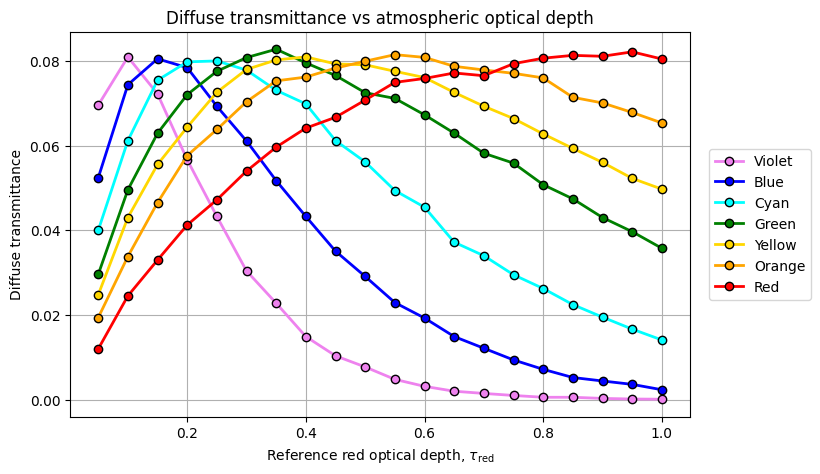

In [ ]:
actual_colors = {
    "violet": "violet",
    "blue": "blue",
    "cyan": "cyan",
    "green": "green",
    "yellow": "gold",
    "orange": "orange",
    "red": "red"
}

color_order = ["violet", "blue", "cyan", "green", "yellow", "orange", "red"]

plt.figure(figsize=(8, 5))

for color_name in color_order:
    subset = theta_df[theta_df["color"] == color_name]

    if subset.empty:
        print(f"No data found for {color_name}")
        continue

    plt.plot(
        subset["tau_ref_red"],
        subset["diffuse_transmittance"],
        marker="o",
        color=actual_colors[color_name],
        markeredgecolor="black",
        linewidth=2,
        label=color_name.capitalize()
    )

plt.xlabel(r"Reference red optical depth, $\tau_{\mathrm{red}}$")
plt.ylabel("Diffuse transmittance")
plt.title("Diffuse transmittance vs atmospheric optical depth")
plt.grid(True)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.show()

# AI Usage

Tool: ChatGPT

Usage:

1. I used AI for all the plotting and figures in this homework.
2. AI was used to create the summary table for the results of the model.
3. The main part I used AI for the model was the scattering loop to determine if a particle reaches the boundaries, continue to scatter, or is absorbed. I manually checked this loop for an shallow atmosphere (1 m) and small number of photons to see if it works fine. Originally, I found a bug in how the pathlength of the photon was calculated, since it was also divided by mu and then was compared to the total pathlength needed to reach the surface. I modified that part and the loop and its logics worked fine.
4. AI was used to clean up the markdown text and write all the equations in the correct format.